# 12. Learned embeddings

Every other page here measures cells with CellProfiler: named features, one per shape or intensity or texture,
in a `var` that says which compartment and which channel each came from. A learned embedding replaces that
block with the output of a neural network — hundreds to a couple of thousand numbers per well that mean nothing
individually.

mantispy does not care. `X` is a matrix, and normalization, hit calling, consensus and the metrics all run on
one as readily as the other. What changes is the recipe around it, what you can no longer ask, and — the part
this page spends most of its length on — what you have to measure instead of assume.

This page uses JUMP-Lite {cite:p}`Munoz_2026`, which is built for exactly this comparison: four plates of the
JUMP Target-2 plate map, one from each of four laboratories, with **the same 1,536 wells** measured six ways —
four learned embeddings, the same architecture as one of them with untrained weights, and one
CellProfiler-equivalent feature set. Swapping the feature block is a
controlled experiment rather than a change of dataset.

Three things about how these numbers were made, because they bound every result below.

- **The images are lossy.** Every one of the six blocks was computed on JPEG-XL medium-quality images. Texture
  measurements and convolutional features are the two things most sensitive to compression, so this is not a
  neutral choice, and it is a property of the benchmark rather than of your screen.
- **One field of view per well.** Full Target-2 acquires nine; JUMP-Lite keeps one. So every cell count below
  is cells *in one field*, and this page cannot show you how to aggregate a model's per-site output — it can
  only tell you, which it does further down.
- **Only one of the six blocks needed segmentation.** `cp_measure` measures objects, so it needs a nucleus and
  a cell body found for every cell. The five embeddings read the whole field and segment nothing. That is the
  real difference between the two columns of this comparison, and it cuts both ways.

In [1]:
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

import mantispy as mt

adata = mt.ds.jump_lite("openphenom")
adata

/Users/tim.treis/Library/Application Support/hatch/env/virtual/mantispy/lPd87khm/tutorials/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AnnData object with n_obs × n_vars = 1536 × 384
    obs: 'Metadata_id', 'Metadata_Source', 'Metadata_Batch', 'Metadata_Plate', 'Metadata_Well', 'Metadata_Site', 'Metadata_model', 'Metadata_dataset', 'Metadata_compression', 'Metadata_CellCount', 'Metadata_JCP2022', 'Metadata_InChIKey', 'Metadata_Perturbation', 'Metadata_Control'
    var: 'object', 'feature_group', 'feature', 'channel', 'scale', 'angle', 'gray_levels', 'radial_bin', 'params', 'is_feature'
    uns: 'mantispy'
    layers: None (.X)

384 numbers per well from OpenPhenom, a Cell Painting foundation model. The metadata is ordinary JUMP
metadata — source, batch, plate, well, and the compound each well received.

The four batches are four different laboratories running one plate map, which makes this a batch-correction
problem with a clean design: whatever separates `source_3` from `source_6` is not biology, because they
received the same compounds in the same wells.

In [2]:
counts = adata.obs.groupby("Metadata_Source", observed=True).agg(
    plate=("Metadata_Plate", "first"),
    wells=("Metadata_Well", "size"),
    controls=("Metadata_Control", "sum"),
    median_cells=("Metadata_CellCount", "median"),
)
# The controls received no compound, so their counts are the site's own density, before any treatment effect.
counts["median_cells, controls"] = (
    adata.obs[adata.obs["Metadata_Control"]].groupby("Metadata_Source", observed=True)["Metadata_CellCount"].median()
)
counts["compounds"] = adata.obs.groupby("Metadata_Source", observed=True)["Metadata_Perturbation"].nunique()
thin = adata.obs["Metadata_CellCount"] < 50
counts["wells under 50 cells"] = thin.groupby(adata.obs["Metadata_Source"], observed=True).sum()
counts

,plate,wells,controls,median_cells,"median_cells, controls",compounds,wells under 50 cells
Metadata_Source,,,,,,,
source_3,JCPQC016,384,64,264.0,282.0,302,28
source_4,BR00121438,384,64,189.0,210.0,302,61
source_5,ACPJUM012,384,64,336.0,357.0,302,13
source_6,110000293081,384,64,254.0,266.0,302,37


## Look at the plates first

One number per laboratory hides where the wells are. Four 384-well plates, coloured by how many cells were
found in the field.

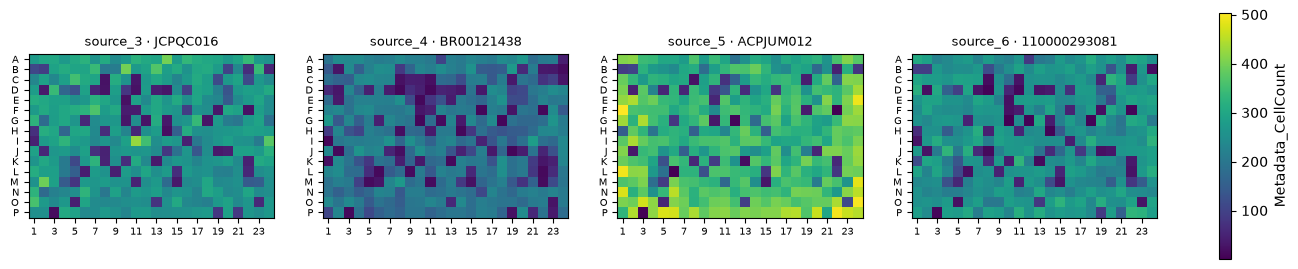

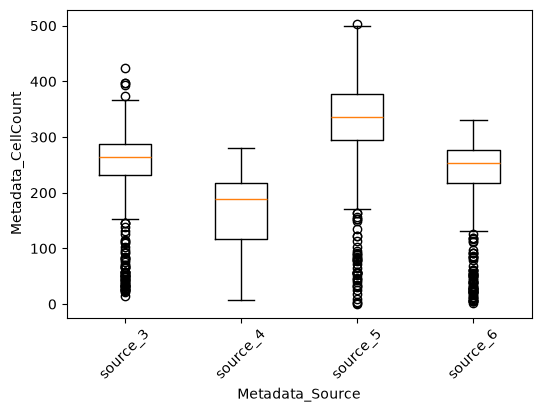

{'share of the plate on the edge': '20%',
 'share of thin wells on the edge': '10%'}

In [3]:
mt.pl.plate(adata, color="Metadata_CellCount", groupby="Metadata_Source", ncols=4)
plt.show()

ax = mt.pl.cell_counts(adata, groupby="Metadata_Source")
plt.show()

row, column = adata.obs["Metadata_Well"].str[0], adata.obs["Metadata_Well"].str[1:].astype(int)
edge = row.isin(["A", "P"]) | column.isin([1, 24])
{
    "share of the plate on the edge": f"{edge.mean():.0%}",
    "share of thin wells on the edge": f"{edge[thin].mean():.0%}",
}

Two facts the rest of the page turns on. The sites run at different densities before any compound acts: the
control wells, which received none, hold a median of 210 cells at `source_4` against 357 at `source_5`. And
the thin wells are not banked against the edge, where evaporation would put them — the edge is a fifth of the
plate but holds only a tenth of the thin wells.

## What `var` no longer tells you

A CellProfiler feature name parses into a compartment, a feature group and a channel. `openphenom_nahualX_17`
has neither. The loader supplies the annotation columns the schema requires and leaves them empty, rather
than letting the name parser loose on names with no structure in them — that parser would read
`openphenom_nahualX_17` as the `nahualX` group of an `openphenom` object, and the screen would quietly
acquire feature families named after the model's own tensors.

In [4]:
both = pd.concat({"openphenom": adata.var, "cp_measure": mt.ds.jump_lite("cp_measure").var}, names=["block"])
display(both.groupby(level="block", sort=False).head(3)[["object", "feature_group", "feature", "channel"]])
# Over every feature, not just the three above: how many are annotated, and with how many distinct values.
both.groupby(level="block", sort=False)[["object", "feature_group", "channel"]].agg(["count", "nunique"])

object  \
block                                                                 
openphenom openphenom_nahualX_0                                 NaN   
           openphenom_nahualX_1                                 NaN   
           openphenom_nahualX_10                                NaN   
cp_measure cell_0/max/ferretMaxFeretDiameter                   cell   
           cell_0/max/ferretMinFeretDiameter                   cell   
           cell_0/max/intensityIntensity_IntegratedIntensity   cell   

                                                             feature_group  \
block                                                                        
openphenom openphenom_nahualX_0                                        NaN   
           openphenom_nahualX_1                                        NaN   
           openphenom_nahualX_10                                       NaN   
cp_measure cell_0/max/ferretMaxFeretDiameter                        ferret   
           cell_0/max/ferretMinFeretDiameter                        ferret   
           cell_0/max/intensityIntensity_IntegratedIntensity     intensity   

                                                                                    feature  \
block                                                                                         
openphenom openphenom_nahualX_0                                                         NaN   
           openphenom_nahualX_1                                                         NaN   
           openphenom_nahualX_10                                                        NaN   
cp_measure cell_0/max/ferretMaxFeretDiameter                               MaxFeretDiameter   
           cell_0/max/ferretMinFeretDiameter                               MinFeretDiameter   
           cell_0/max/intensityIntensity_IntegratedIntensity  Intensity_IntegratedIntensity   

                                                             channel  
block                                                                 
openphenom openphenom_nahualX_0                                  NaN  
           openphenom_nahualX_1                                  NaN  
           openphenom_nahualX_10                                 NaN  
cp_measure cell_0/max/ferretMaxFeretDiameter                       0  
           cell_0/max/ferretMinFeretDiameter                       0  
           cell_0/max/intensityIntensity_IntegratedIntensity       0

object         feature_group         channel        
            count nunique         count nunique   count nunique
block                                                          
openphenom      0       0             0       0       0       0
cp_measure   2550       2          2550       7    2550       5

That is the contrast the rest of the page is about, in one table. `cp_measure` names a compartment, a feature
group and a channel for every column; the embedding names nothing.

One caveat on the channel: `cp_measure` numbers its inputs `0` to `4` rather than naming them, because the
stain each index stands for lives in the acquisition metadata and not in the feature name. mantispy keeps the
index rather than guessing a stain.

This is not a defect of the embedding, it is the honest answer: it has no notion of a channel or a
compartment. The consequence is that anything keyed on the feature annotation has nothing to work with.
`pl.effect_sizes` colours its bars by feature family, `tl.feature_sets` groups features into sets, and the
CellProfiler blocklist names features to drop — none of them have anything to key on.

What survives is everything that treats a feature as an anonymous number: normalization, sphering, distances,
hit calling, consensus, and every metric. And the family colouring is recoverable, which is what the section
on interpreting an embedding does further down.

## Bringing your own embedding

`ds.jump_lite` is a convenience. An embedding you produced yourself is a matrix and a metadata frame, and
`io.stamp` is what puts it on the mantispy API surface.

In [5]:
# Pretend this came out of your own model, one row per well. Join on the index rather than slicing both by
# position: ds.jump_lite sorts its blocks into one row order, but two tables from different pipelines rarely
# share one.
wells_i_have = adata.obs_names[:8]
values = np.asarray(adata[wells_i_have].X, dtype=np.float32)
metadata = adata.obs.loc[wells_i_have, ["Metadata_Plate", "Metadata_Well", "Metadata_Perturbation", "Metadata_Control"]]

mine = ad.AnnData(values, obs=metadata.copy())
mine.var_names = [f"mymodel_{index}" for index in range(values.shape[1])]
mt.io.stamp(mine, resolution="well")
print(mt.io.validate(mine))

`io.stamp` supplies the annotation columns empty rather than parsing the feature names, and records the
resolution, so the object validates and can be written to h5ad. Supplying them empty is the point: the parser
would read `mymodel_17` as structure it does not have.

Two things worth copying from that cell. `values` is cast to **float32** — a model's output often arrives
as float64 once it has been through pandas or a parquet file, and at 100,000 wells by 1,536 dimensions that is
1.2 GB against 600 MB. And the warning is
*printed*, not counted: it names `Metadata_CellCount` as missing, which is the one column the rest of this
page shows you cannot do without.

### Aggregating a model's output to a well

JUMP-Lite gives one field of view per well, so this page never has to do it, and your screen will. The
difference matters more than it looks:

- A **CellProfiler** profile is a per-cell measurement aggregated over cells and fields, and the median is the
  pycytominer default because per-cell features are heavy-tailed. `tl.aggregate(by=("Metadata_Plate",
  "Metadata_Well"), func="median")` is the call.
- An **embedding** is a function of a whole image, so per-field embeddings are vectors in a learned basis. A
  per-coordinate median is not a point the model would ever emit. Prefer the mean, and if you take the median
  know that you have left the model's output manifold.

`tl.aggregate`'s `min_cells` guard counts rows, so it does nothing when the rows are already fields rather
than cells. Check the field count yourself.

## The recipe

**Normalize as usual.** The embedding is the model's raw output on each well's images: it carries the plate's
staining and illumination just as CellProfiler features do, so a per-plate normalization against the negative
controls is still the first step. Illumination correction is not part of this — it happens upstream, on the
images, and no per-plate normalization of the profiles substitutes for it.

In [6]:
mt.pp.normalize(adata, method="mad_robustize", by="Metadata_Plate", reference="negcon")
classical = mt.ds.jump_lite("cp_measure")
mt.pp.normalize(classical, method="mad_robustize", by="Metadata_Plate", reference="negcon")
{
    f"{name}, unusable after normalizing": f"{int(block.var['degenerate_scale'].sum())} of {block.n_vars}"
    for name, block in (("openphenom", adata), ("cp_measure", classical))
}

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_36754/1709152324.py:3: UserWarning: 30 of 2550 features have no reference values to centre on in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon', because every value there is missing or infinite. Their centre is set to 0 where it is missing and their scale to 1, so the values measured outside the reference rows pass through unnormalized instead of becoming NaN, and are not comparable across groups. They are flagged in var['degenerate_scale'], and pp.feature_select drops them by default; to drop them now, adata = adata[:, ~adata.var['degenerate_scale']].copy().
  mt.pp.normalize(classical, method="mad_robustize", by="Metadata_Plate", reference="negcon")
/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_36754/1709152324.py:3: UserWarning: 103 of 2550 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Adding epsilon=1e-18 to

{'openphenom, unusable after normalizing': '0 of 384',
 'cp_measure, unusable after normalizing': '133 of 2550'}

The warnings above split that second number into its two very different causes: 103 features with **no
spread** among the control wells of at least one plate, and 30 with **no control values at all** to centre on
there. Both are
flagged in `var["degenerate_scale"]`, and only the first is what "constant among the controls" usually means.
Not one embedding dimension falls into either category. `pp.feature_select` drops flagged features first,
with `drop_degenerate`, and judges the rest without them, so every selection below starts from the 2,417.

### Select features on the CellProfiler block. Do not select them on an embedding.

This is the one step where the two block types genuinely need different treatment, and holding it identical
would be the unfair comparison, not the fair one.

`cp_measure` is a list of measurements, and measurements come with the usual pathologies: ones that never
vary, ones that duplicate each other, ones that run away to enormous values. pycytominer's standard selection
is built for exactly that. Run it and watch what each step is worth here.

In [7]:
PYCYTOMINER = ("variance_threshold", "correlation_threshold", "drop_na_columns", "blocklist")
# feature_select's own default: drop_degenerate, which removes only what normalize flagged, then pycytominer's.
DEFAULT = ("drop_degenerate", *PYCYTOMINER)

selection = {}
for label, operations in {
    "none": ("drop_degenerate", "drop_na_columns"),
    "pycytominer default": DEFAULT,
    "default + drop_outliers": (*DEFAULT, "drop_outliers"),
    "+ noise_removal": (*DEFAULT, "drop_outliers", "noise_removal"),
}.items():
    trial = classical.copy()
    mt.pp.feature_select(trial, operations=operations, na_cutoff=0.0)
    trial = mt.pp.subset_features(trial)
    selection[label] = {
        "features": trial.n_vars,
        "largest |value|": float(np.abs(np.asarray(trial.X)).max()) if trial.n_vars else np.nan,
    }
pd.DataFrame(selection).T

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_36754/1604515389.py:13: UserWarning: feature_select flagged none of the 2550 features as selected; uns['mantispy']['feature_select'] says what each operation removed. Every cutoff here is an absolute threshold on the scale pp.normalize left the values on, so check it against that scale; noise_removal's stdev_cutoff is the usual cause.
  mt.pp.feature_select(trial, operations=operations, na_cutoff=0.0)


,features,largest |value|
none,1949.0,178622.234375
pycytominer default,540.0,178622.234375
default + drop_outliers,526.0,456.745605
+ noise_removal,0.0,NaN


Read the second column. Left alone, `cp_measure` carries values of order 1e5, which survive a robust
per-plate normalization because they are not constant, merely enormous. **The pycytominer default does not
remove them**: it cuts the block to about a quarter of its features and leaves the largest value exactly where
it was. It takes `drop_outliers`, which is in `pp.OPERATIONS` and not in the default set, and that removes
only fourteen more features while bringing the largest value down about four-hundred-fold. A principal
component analysis puts its first components wherever the variance is largest, which is why a handful of
columns this far out are worth removing before it runs.

`noise_removal` empties the block. Its cutoff is an absolute standard deviation, and on the scale
`mad_robustize` leaves no feature falls under it — a reminder that a selection step tuned for one
normalization is not portable to another.

So this page runs the standard selection plus `drop_outliers` on `cp_measure`, and nothing at all on the
embeddings. The argument for the second half is that the dimensions of an embedding are a basis rather than a
list of measurements: dropping some of them because they correlate discards the geometry the model learned.
That argument is about *variance and correlation* filters, though, and it does not cover every filter. The
one that does apply is reproducibility, which uses the replicate structure rather than the feature's own
distribution.

In [8]:
icc = adata.copy()
mt.pp.feature_reproducibility(icc, groupby="Metadata_Perturbation", min_icc=0.2)
{
    "dimensions with ICC > 0.2": f"{int(icc.var['icc_selected'].sum())} of {icc.n_vars}",
    "median ICC": round(float(icc.var["icc"].median()), 3),
}

{'dimensions with ICC > 0.2': '351 of 384', 'median ICC': 0.502}

That is a number to report rather than a filter to apply blindly, and it is the honest substitute for the
blocklist, which matches CellProfiler's feature *names* and so has nothing to say about an embedding, and is
not written for `cp_measure`'s naming convention either.

## Comparing six feature sets

The question is not whether an embedding works, but how it compares with the alternatives on the same wells.
Two readouts:

- **`tl.map`** — mean average precision. Rank every other profile by similarity to a query and ask whether
  its replicates come first. The pairs are defined so that a replicate must come from a *different
  laboratory*, which is the cross-site reproducibility question, and copairs gives every compound a
  permutation p-value that is then BH-corrected. This is the metric the JUMP benchmarks report
  {cite:p}`Kalinin_2025,Arevalo_2024`, and it is the only one of the two that scales: the
  similarity-matrix readouts build a dense n-by-n matrix and stop at about 22,000 profiles.
- **`metrics.known_relationships`** — of the compounds annotated to act on the same gene, how many end up in
  either tail of the similarity distribution?

Each is measured under three alignments: the principal components alone, `pp.tvn`, and `pp.harmony`, which
ranked top-three in every scenario of the batch-correction benchmark {cite:p}`Arevalo_2024` and is the last
step of the JUMP recipe. `pp.harmony` needs the optional extra, `pip install 'mantispy[harmony]'`.

In [9]:
targets = mt.ds.jump_lite_targets()


def align(wells):
    """The three alignments every block is compared under: none, TVN and Harmony, on the same 50 components."""
    sc.pp.pca(wells, n_comps=50)
    mt.pp.tvn(wells, batch_key="Metadata_Source", use_rep="X_pca", key_added="X_tvn")
    mt.pp.harmony(wells, batch_key="Metadata_Source", use_rep="X_pca", key_added="X_harmony")
    return wells


def prepared(model):
    """Load one feature set and align it three ways.

    The CellProfiler block gets the standard selection; the embeddings get none, for the reason above.
    """
    wells = mt.ds.jump_lite(model)
    mt.pp.normalize(wells, method="mad_robustize", by="Metadata_Plate", reference="negcon")
    operations = (*DEFAULT, "drop_outliers") if model == "cp_measure" else ("drop_degenerate", "drop_na_columns")
    mt.pp.feature_select(wells, operations=operations, na_cutoff=0.0)
    return align(mt.pp.subset_features(wells))


def treated_profiles(wells, rep):
    """One alignment of the treated wells, as an object the metrics can score."""
    treated = ~wells.obs["Metadata_Control"].to_numpy()
    profiles = ad.AnnData(np.asarray(wells.obsm[rep], dtype=np.float32)[treated], obs=wells.obs[treated].copy())
    mt.io.stamp(profiles, resolution="well")
    return profiles


blocks = {model: prepared(model) for model in mt.ds.JUMP_LITE_MODELS}
{model: wells.n_vars for model, wells in blocks.items()}

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_36754/2337959602.py:18: UserWarning: 30 of 2550 features have no reference values to centre on in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon', because every value there is missing or infinite. Their centre is set to 0 where it is missing and their scale to 1, so the values measured outside the reference rows pass through unnormalized instead of becoming NaN, and are not comparable across groups. They are flagged in var['degenerate_scale'], and pp.feature_select drops them by default; to drop them now, adata = adata[:, ~adata.var['degenerate_scale']].copy().
  mt.pp.normalize(wells, method="mad_robustize", by="Metadata_Plate", reference="negcon")
/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_36754/2337959602.py:18: UserWarning: 103 of 2550 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Adding epsilon=1e-18 to t

{'openphenom': 384,
 'dinov2': 384,
 'dinov2_random': 384,
 'subcell': 1536,
 'morphem': 1920,
 'cp_measure': 526}

In [10]:
CROSS_LAB = {
    "pos_sameby": ["Metadata_Perturbation"],
    "pos_diffby": ["Metadata_Source"],  # a replicate pair has to cross laboratories
    "neg_diffby": ["Metadata_Perturbation"],
}
scored_profiles = {}


def scored(name, wells, rep):
    """Cross-laboratory mAP on wells, and target recall on consensus profiles against its own null."""
    profiles = treated_profiles(wells, rep)
    mt.tl.map(profiles, **CROSS_LAB, null_size=10_000)  # the default; the note under the table says why not fewer
    per_compound = profiles.uns["mantispy"]["map"]
    scored_profiles[name, rep] = profiles  # kept so the per-compound panels below need not score again

    consensus = mt.tl.consensus(profiles, method="median", min_replicates=1)
    # Chance is measured, not assumed to be 10%; the section on chance below says why.
    recall = mt.metrics.known_relationships(consensus, targets, n_permutations=100, seed=0).iloc[0]
    return {
        "mAP": float(per_compound["mean_average_precision"].mean()),
        "significant": int(per_compound["below_corrected_p"].sum()),
        "target recall": float(recall["value"]),
        "recall null": float(recall["null"]),
        "recall p": float(recall["p_value"]),
        "source variance": float(mt.metrics.pc_regression(wells, key="Metadata_Source", use_rep=rep)["value"].iloc[0]),
    }


comparison = pd.DataFrame(
    [
        {"model": model, "alignment": rep, **scored(model, wells, rep)}
        for model, wells in blocks.items()
        for rep in ("X_pca", "X_tvn", "X_harmony")
    ]
)
comparison.pivot(index="model", columns="alignment", values=["mAP", "significant"]).round(3)

mAP               significant            
alignment     X_harmony  X_pca  X_tvn   X_harmony X_pca X_tvn
model                                                        
cp_measure        0.074  0.050  0.026       106.0  32.0   4.0
dinov2            0.068  0.031  0.029        75.0   5.0   5.0
dinov2_random     0.010  0.009  0.010         0.0   0.0   0.0
morphem           0.087  0.027  0.035        93.0   3.0   6.0
openphenom        0.037  0.016  0.018         4.0   0.0   3.0
subcell           0.075  0.027  0.022        73.0   2.0   2.0

`significant` counts the compounds whose mAP survives a BH correction over the 301 tested, which is the
number a screener actually cares about: how many compounds would you have called.

That count depends on the size of the permutation null in a way that is easy to miss. copairs cannot return a
p-value below one over the number of draws plus one, so with too few draws every compound's p is floored, and
a correction over 301 compounds at the default 5% threshold then needs a number of them sitting at that floor
before it calls any at all — thirteen at 500 draws, more with fewer. The cell below scores the same profiles both ways.

In [11]:
profiles = scored_profiles["cp_measure", "X_pca"]  # already scored with 10,000 draws
tables = {
    500: mt.tl.map(profiles, **CROSS_LAB, null_size=500, copy=True).uns["mantispy"]["map"],
    10_000: profiles.uns["mantispy"]["map"],
}
pd.DataFrame(
    [
        {
            "null draws": draws,
            "smallest possible p": 1 / (draws + 1),
            "smallest p reached": float(table["p_value"].min()),
            "compounds called": int(table["below_corrected_p"].sum()),
        }
        for draws, table in tables.items()
    ]
).set_index("null draws")

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_36754/2150697818.py:3: UserWarning: with null_size=500 no p-value can fall below 1/501, so the correction over 301 groups calls none of them unless at least 13 reach that floor together. Raise null_size above 6020 for one group to be callable on its own.
  500: mt.tl.map(profiles, **CROSS_LAB, null_size=500, copy=True).uns["mantispy"]["map"],


,smallest possible p,smallest p reached,compounds called
null draws,,,
500,0.001996,0.001996,0
10000,0.000100,0.000100,32


With 500 draws the smallest p any compound can reach is 0.002, and not enough of them reach it together for
the correction to call one. With 10,000 the same profiles call the 32 the table above reports for
`cp_measure` uncorrected. Only this one block and alignment was scored at 500 draws, but the arithmetic is the same for the
others, so use the default.

Four things to read out of the comparison table.

**The untrained model behaves like one.** `dinov2_random` is the same architecture with random weights, and
it is the control for the whole comparison. Its mAP sits at the floor under every alignment, because random
projections of an image do not reproduce across laboratories, and no correction manufactures structure out of
noise. Every other block beats it on mAP under every alignment, which is the least a pipeline has to show.

**Uncorrected, the classical block reproduces and the embeddings barely do.** Look at the `X_pca` column of
`significant`: `cp_measure` calls 32 of the 301 compounds across laboratories with no batch correction at all,
and the learned embeddings call between none and five. After `pp.harmony` four of the blocks call 73 to 106;
`openphenom` calls four. The embeddings need the correction to reproduce across sites much more than the
named measurements do.

**Alignment matters as much as the choice of model.** `pp.harmony` lifts the mAP of every block but the
untrained one, by 1.5 to 3.2 times. Under Harmony, the choice of block then moves it again by more
than a factor of two, and the number of compounds called from four to 106. `pp.tvn` does little for
retrieval: no block calls more than six compounds under it. It adds a few on MorphEm and OpenPhenom, and on
`cp_measure` it cuts the 32 uncorrected calls to four. Neither the model nor the correction is the
small decision.

**The CellProfiler-equivalent set leads without a correction.** `cp_measure` tops the uncorrected column
and calls the most compounds under Harmony — though MorphEm's mean mAP under Harmony is higher, SubCell's and
DINOv2's are level with it, and under TVN `cp_measure` falls behind MorphEm and DINOv2.

Each of those compounds had to be told apart from *other compounds*, across laboratories. The JUMP-Lite
benchmark {cite:p}`Munoz_2026` also scores an easier question, phenotypic activity: do a compound's replicates
stand apart from the negative controls on the query's own plate? `tl.map` computes it with
`mode="activity"`, which keeps the controls in and retrieves against the ones plated beside each query.

In [12]:
def activity(wells, rep):
    """Phenotypic activity: do a compound's replicates retrieve each other against the controls on their plate?"""
    table = mt.tl.map(wells, mode="activity", use_rep=rep, copy=True).uns["mantispy"]["map"]
    return {
        "activity mAP": float(table["mean_average_precision"].mean()),
        "active": int(table["below_corrected_p"].sum()),
    }


activities = pd.DataFrame(
    [
        {"model": model, "alignment": rep, **activity(wells, rep)}
        for model, wells in blocks.items()
        for rep in ("X_pca", "X_tvn", "X_harmony")
    ]
)
activities.pivot(index="model", columns="alignment", values=["activity mAP", "active"]).round(3)

activity mAP                  active             
alignment        X_harmony  X_pca  X_tvn X_harmony X_pca  X_tvn
model                                                          
cp_measure           0.333  0.301  0.302      97.0  88.0   78.0
dinov2               0.317  0.275  0.327      92.0  78.0   99.0
dinov2_random        0.129  0.114  0.157       2.0   2.0    2.0
morphem              0.318  0.269  0.345      98.0  81.0  106.0
openphenom           0.293  0.251  0.267      88.0  70.0   83.0
subcell              0.306  0.261  0.290      89.0  77.0   84.0

On activity the blocks are close. `cp_measure` leads without a correction and on mean mAP under Harmony;
MorphEm leads under TVN and is level with it on the count under Harmony; DINOv2 is near both. Under TVN
every trained embedding calls more compounds active than `cp_measure` does. OpenPhenom has the lowest mean mAP
of the five real blocks under every alignment. The untrained model calls two compounds under every alignment,
at 0.11 to 0.16 mAP against 0.25 to 0.35 for the real blocks.

Hold that next to the cross-laboratory table rather than choosing between them. For 282 of the 301
compounds every replicate sits at another laboratory, so both readouts ask a query to find replicates run
elsewhere; what changes is what they have to outrank. (The 19 compounds plated twice also have a replicate on
their own plate, which activity counts and the cross-laboratory readout does not — too few to matter below.)
Uncorrected, against the controls on their own plate, the trained embeddings find those replicates for 70 to
81 compounds and `cp_measure` for 88. Against *other compounds* they manage five at most, and `cp_measure` 32.
Even if all 19 twice-plated compounds were active only through their same-plate replicate, the embeddings
would keep more than fifty.

So, without a batch correction, the learned embeddings tell a compound from DMSO nearly as well as the named
measurements do, and have much more trouble telling one compound from another across laboratories. Harmony
narrows that. After it, MorphEm, SubCell and DINOv2 reach a cross-laboratory mAP of 0.087, 0.075 and 0.068
against `cp_measure`'s 0.074, and call 73 to 93 compounds against its 106 — MorphEm closing most of the gap in
calls, while DINOv2 and SubCell draw level on mAP but stay about thirty calls behind, as they were uncorrected. A correction that removes the laboratory narrowing the gap is what you
would see if these embeddings carry more of the laboratory than `cp_measure` does, and their uncorrected source
variance in the table below (about 0.03 to 0.04, against 0.02) points the same way. OpenPhenom is the exception: it calls four even after Harmony, and no more than eight under any of the seeds below.

Two conditions bound all of this. The embeddings are used out of the box, as the benchmark also uses them,
without fine-tuning to Cell Painting data, and they are computed from lossy-compressed JUMP images with one
fixed preprocessing. Either could move the comparison, so treat the ranking as a property of this setup, not
of the models.

### How much of the Harmony column is the seed

`pp.harmony` clusters the wells before it corrects them, and the clustering starts from a random draw, so the
seed moves the result, and so does the order of the rows, which the draw is taken over. The tables above are
one run each. Here is every block under five seeds.

In [13]:
spread = []
for model, wells in blocks.items():
    for seed in range(5):
        mt.pp.harmony(wells, batch_key="Metadata_Source", use_rep="X_pca", key_added="X_harmony_seed", seed=seed)
        profiles = treated_profiles(wells, "X_harmony_seed")
        mt.tl.map(profiles, **CROSS_LAB)
        spread.append(
            {
                "model": model,
                "cross-laboratory mAP": float(profiles.uns["mantispy"]["map"]["mean_average_precision"].mean()),
                "cross-laboratory calls": int(profiles.uns["mantispy"]["map"]["below_corrected_p"].sum()),
                **activity(wells, "X_harmony_seed"),
            }
        )
pd.DataFrame(spread).groupby("model").agg(["min", "max"]).round(3)

cross-laboratory mAP        cross-laboratory calls       \
                               min    max                    min  max   
model                                                                   
cp_measure                   0.073  0.079                     96  106   
dinov2                       0.068  0.077                     69   76   
dinov2_random                0.010  0.011                      0    0   
morphem                      0.085  0.087                     90   95   
openphenom                   0.037  0.040                      2    8   
subcell                      0.074  0.077                     68   73   

              activity mAP        active       
                       min    max    min  max  
model                                          
cp_measure           0.331  0.339     97  101  
dinov2               0.317  0.322     92   94  
dinov2_random        0.127  0.131      1    2  
morphem              0.318  0.320     97   98  
openphenom           0.293  0.296     88   91  
subcell              0.302  0.307     87   91

Five seeds move `cp_measure` between 96 and 106 compounds called across laboratories, MorphEm between 90 and
95, DINOv2 and SubCell between 68 and 76, and OpenPhenom between two and eight; the untrained model calls
none under any of them. The three tiers of calls survive every seed: `cp_measure` and MorphEm above DINOv2 and SubCell,
OpenPhenom far below. So does the order inside the first tier: `cp_measure` calls more compounds than MorphEm
under every seed, and MorphEm has the higher cross-laboratory mAP under every seed. What does not survive is a
gap of a few compounds, or of a few thousandths of mAP, between two blocks in one run: DINOv2 and SubCell
overlap on both, and on the activity count so do `cp_measure` and MorphEm, at 97 to 101 compounds active against 97 to
98. Read the Harmony column as a range, and compare two pipelines under Harmony over several seeds rather
than one.

### One preprocessing choice moves the CellProfiler result

JUMP-Lite's CellProfiler preparation includes a rank-based inverse normal transform {cite:p}`Munoz_2026`,
which this page leaves out; `pp.rank_int` computes it. It makes every feature's distribution the same shape,
which can matter a great deal for a block of measurements on wildly different scales. Here is `cp_measure`
both ways. The correlation filter then runs on the transformed values, so a somewhat different set of features
survives, and the table says how many.

In [14]:
def with_rank_int():
    """cp_measure prepared in the benchmark's order: the rank transform before the correlation filter."""
    wells = classical.copy()
    mt.pp.feature_select(
        wells, operations=("drop_degenerate", "drop_na_columns", "variance_threshold", "drop_outliers"), na_cutoff=0.0
    )
    wells = mt.pp.subset_features(wells)
    mt.pp.rank_int(wells, by="Metadata_Plate", stochastic=False)
    mt.pp.feature_select(wells, operations=("correlation_threshold", "blocklist"))
    return align(mt.pp.subset_features(wells))


ranked = with_rank_int()
recipes = pd.concat(
    [
        comparison.merge(activities)
        .query("model == 'cp_measure' and alignment != 'X_tvn'")
        .assign(recipe="as above", features=blocks["cp_measure"].n_vars),
        pd.DataFrame(
            [
                {"alignment": rep, **scored("cp_measure, with rank INT", ranked, rep), **activity(ranked, rep)}
                for rep in ("X_pca", "X_harmony")
            ]
        ).assign(recipe="with rank INT", features=ranked.n_vars),
    ]
)
recipes.set_index(["recipe", "alignment"])[
    ["features", "significant", "target recall", "recall null", "recall p", "activity mAP", "active"]
].rename(columns={"significant": "cross-laboratory calls"}).round(3)

features  cross-laboratory calls  target recall  \
recipe        alignment                                                    
as above      X_pca           526                      32          0.089   
              X_harmony       526                     106          0.077   
with rank INT X_pca           603                      19          0.164   
              X_harmony       603                      50          0.149   

                         recall null  recall p  activity mAP  active  
recipe        alignment                                               
as above      X_pca            0.051      0.01         0.301      88  
              X_harmony        0.052      0.01         0.333      97  
with rank INT X_pca            0.112      0.01         0.283      84  
              X_harmony        0.115      0.01         0.299      80

The transform cuts `cp_measure`'s cross-laboratory calls from 32 to 19 uncorrected and from 106 to 50 under
Harmony. Its raw annotation recall roughly doubles, but so does its null, so the gain over chance is modest:
the margin grows from 0.038 to 0.052 uncorrected and from 0.025 to 0.034 under Harmony. It is the trap the
section on chance below warns about: a raw recall that looks better mostly because its null rose with it. Its
effect on activity
depends on the alignment: small uncorrected, and under Harmony enough to drop `cp_measure` from first to below
MorphEm and DINOv2 on activity mAP, and from level with MorphEm at the top of the count to last. Under Harmony it also leaves `cp_measure` calling fewer
compounds across laboratories than MorphEm, DINOv2 or SubCell. So where the CellProfiler block ranks against
the embeddings here depends on a preprocessing step, not only on the features. The tables above keep this
page's recipe; this one is the reason not to read their `cp_measure` row as the CellProfiler result.

Before reading either ranking further, look at what 50 components means for each block.

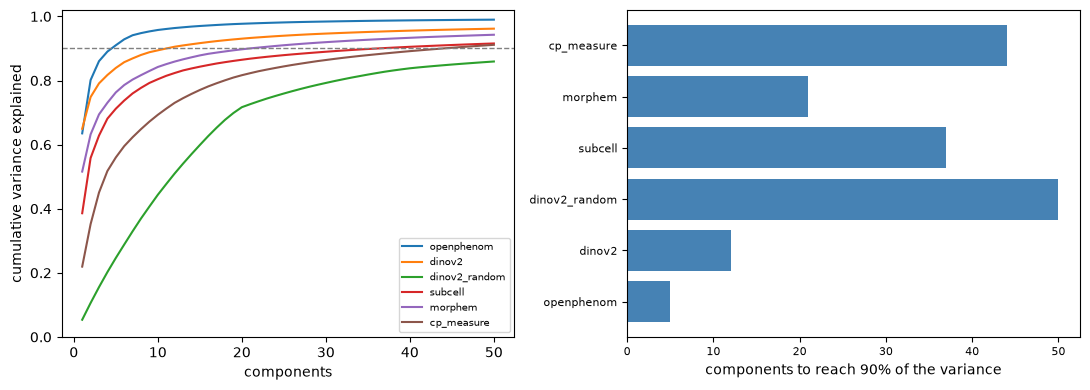

,first component,components to 90%
openphenom,0.635,5
dinov2,0.650,12
dinov2_random,0.054,> 50
subcell,0.386,37
morphem,0.516,21
cp_measure,0.219,44


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for model, wells in blocks.items():
    ratio = wells.uns["pca"]["variance_ratio"]
    axes[0].plot(np.arange(1, len(ratio) + 1), np.cumsum(ratio), label=model, lw=1.5)
axes[0].axhline(0.9, color="grey", ls="--", lw=1)
axes[0].set(xlabel="components", ylabel="cumulative variance explained", ylim=(0, 1.02))
axes[0].legend(fontsize=7)

reach = pd.Series(
    {
        model: int(np.searchsorted(np.cumsum(wells.uns["pca"]["variance_ratio"]), 0.9) + 1)
        for model, wells in blocks.items()
    }
)
axes[1].barh(reach.index, reach.clip(upper=50), color="steelblue")
axes[1].set_xlabel("components to reach 90% of the variance")
axes[1].tick_params(labelsize=8)
fig.tight_layout()
plt.show()

pd.DataFrame(
    {
        "first component": {model: float(wells.uns["pca"]["variance_ratio"][0]) for model, wells in blocks.items()},
        # Past 50, 90% was never reached inside the 50 components computed.
        "components to 90%": reach.where(reach <= 50, "> 50"),
    }
).round(3)

This is the caveat on every row of the table above: `sc.pp.pca(n_comps=50)` keeps 90% of the variance of all
five real blocks, easily for OpenPhenom and only just for `cp_measure`, and falls short of it only for the
untrained control. OpenPhenom and DINOv2 put most of their variance in a handful of
components; the untrained model spreads it far more evenly, with 5% in its first component against 39 to 65%
for the trained ones, and does not reach 90% within the fifty computed. SubCell and MorphEm sit between. And
`cp_measure` needs 44, more than any of the trained embeddings, which is what a few hundred distinct
measurements look like rather than a sign of noise. Fifty components is not a neutral choice
held constant across the six: it is the same number applied to six different geometries, and it keeps less of
some than of others.

### What is chance, really?

`metrics.known_relationships` counts annotated pairs falling in either tail of the similarity distribution,
and a fixed tail width invites the assumption that a map with no information scores 10%. Here it does not.
The tails hold 10% of all pairs, so pairs drawn at random would land there 10% of the time. The annotated
pairs are not drawn at random: RefChemDB links some compounds to hundreds of genes and most to a few, so a
handful of compounds make up many of the pairs, and chance moves with where each representation puts those
few. So the chance level has to be measured. `n_permutations` shuffles which compound each annotation row
names, keeping every gene's number of compounds and every compound's number of genes, and reports the mean
recall over the shuffles as `null` and the share of shuffles that recall at least as much as `p_value`.

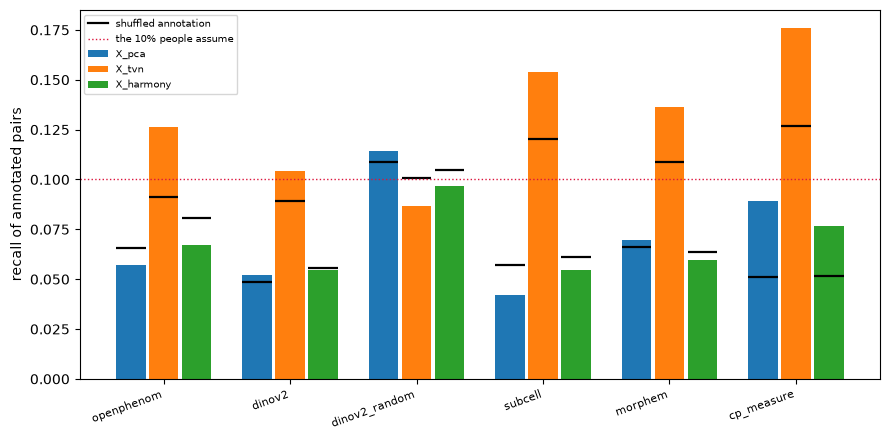

target recall               recall null                recall p  \
alignment         X_harmony  X_pca  X_tvn   X_harmony  X_pca  X_tvn X_harmony   
model                                                                           
cp_measure            0.077  0.089  0.176       0.052  0.051  0.127     0.010   
dinov2                0.055  0.052  0.104       0.055  0.049  0.089     0.564   
dinov2_random         0.097  0.114  0.087       0.105  0.109  0.101     0.812   
morphem               0.060  0.069  0.136       0.064  0.066  0.109     0.673   
openphenom            0.067  0.057  0.127       0.081  0.066  0.091     0.970   
subcell               0.055  0.042  0.154       0.061  0.057  0.120     0.812   

                             
alignment      X_pca  X_tvn  
model                        
cp_measure     0.010  0.010  
dinov2         0.307  0.059  
dinov2_random  0.248  0.980  
morphem        0.356  0.010  
openphenom     0.851  0.010  
subcell        0.990  0.010

In [16]:
fig, ax = plt.subplots(figsize=(9, 4.5))
order = list(blocks)
width = 0.26
for offset, alignment in zip((-width, 0, width), ("X_pca", "X_tvn", "X_harmony"), strict=True):
    block = comparison[comparison["alignment"] == alignment].set_index("model").loc[order]
    x = np.arange(len(order)) + offset
    ax.bar(x, block["target recall"], width * 0.9, label=alignment)
    # the shuffled-annotation level for this exact representation
    ax.hlines(block["recall null"], x - width * 0.45, x + width * 0.45, color="black", lw=1.6)
ax.plot([], [], color="black", lw=1.6, label="shuffled annotation")
ax.axhline(0.10, color="crimson", ls=":", lw=1, label="the 10% people assume")
ax.set_xticks(np.arange(len(order)), order, rotation=20, ha="right", fontsize=8)
ax.set_ylabel("recall of annotated pairs")
ax.legend(fontsize=7)
fig.tight_layout()
plt.show()

comparison.pivot(index="model", columns="alignment", values=["target recall", "recall null", "recall p"]).round(3)

The black bars are chance for that representation, and they are not a constant 10%: for the trained embeddings and
`cp_measure` they run from 5 to 8% without TVN and 9 to 13% with it, and for the untrained model they sit at
10 to 11% under every alignment. Read every recall against the bar sitting on it, not
against the red line.

Once you do, the readout says something clean, and something different from what the raw numbers suggest.
**`pp.tvn` lifts recall clearly above its own null on three of the four trained embeddings and on
`cp_measure`, and on DINOv2 only marginally (p = 0.06, five of the 100 shuffles scoring as high).
Under either of the other two alignments no embedding clears its own null — but `cp_measure` clears it under
all three.** And the
untrained model never clears it: its apparently high raw recall, the highest in the unaligned column, is
entirely a property of its null, which is high because a near-random projection spreads pairs into the tails.
That is exactly the trap a fixed baseline sets: in the unaligned and Harmony columns it would have made the
untrained control look like the best model on the page.

The shuffled annotation is what exposed the fixed baseline; the untrained model is where it would have done
the most damage. Keeping one in the comparison is the cheapest check that a pipeline measures anything.

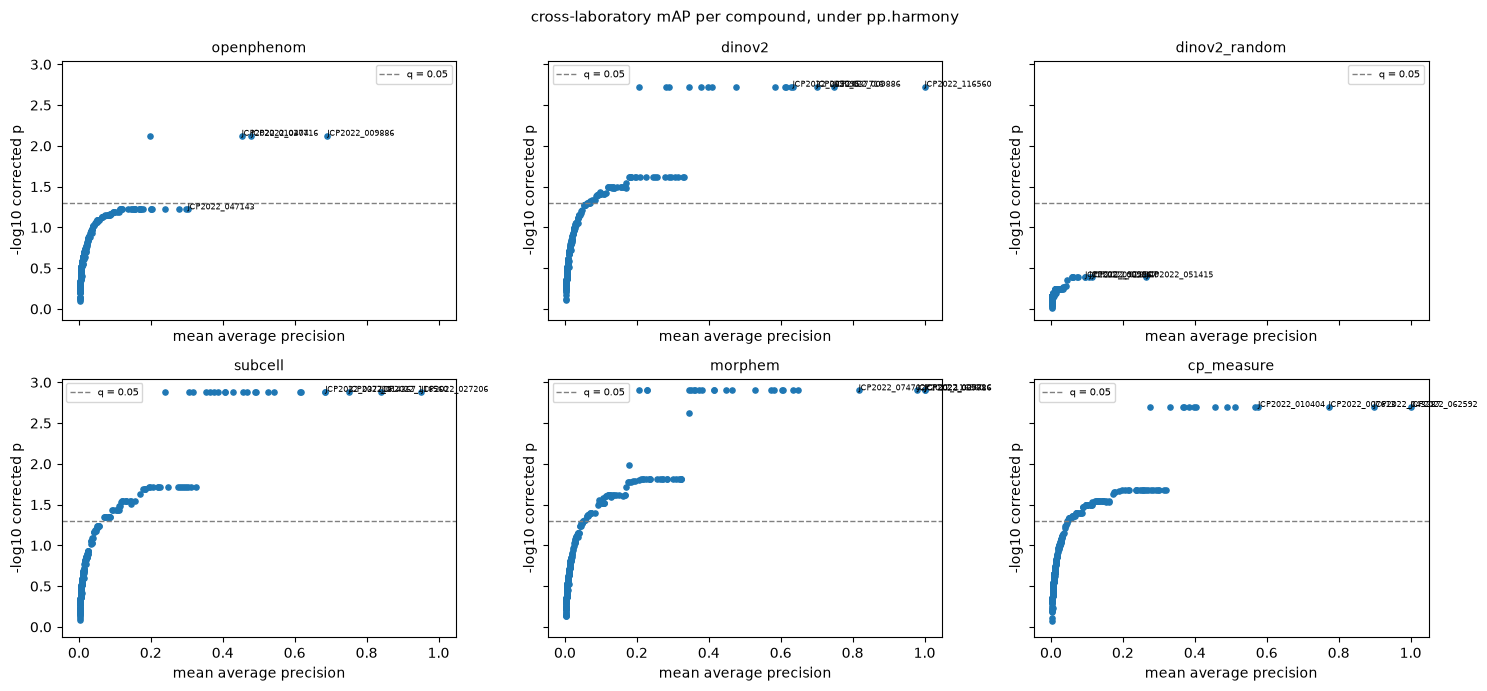

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True, sharey=True)
for ax, model in zip(axes.ravel(), blocks, strict=True):
    mt.pl.map(scored_profiles[model, "X_harmony"], label_top=4, ax=ax)
    ax.set_title(model, fontsize=10)
fig.suptitle("cross-laboratory mAP per compound, under pp.harmony", fontsize=11)
fig.tight_layout()
plt.show()

An aggregate mAP hides whether it came from many mediocre compounds or a few excellent ones. These panels
show which, and name the compounds at the top.

## The laboratories

The same `metrics.pc_regression`, now on the source.

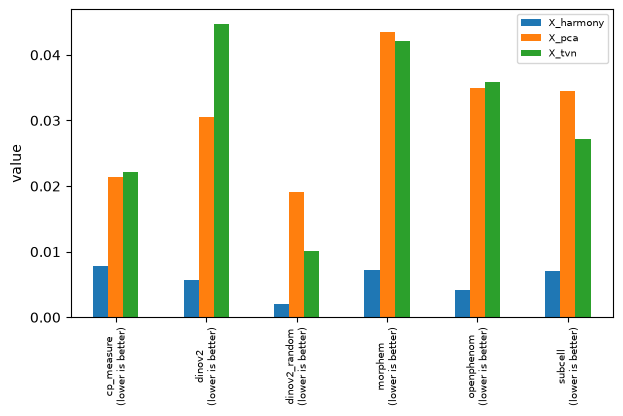

alignment,X_harmony,X_pca,X_tvn
model,,,
cp_measure,0.008,0.021,0.022
dinov2,0.006,0.030,0.045
dinov2_random,0.002,0.019,0.010
morphem,0.007,0.044,0.042
openphenom,0.004,0.035,0.036
subcell,0.007,0.034,0.027


In [18]:
# pl.metrics groups by "metric" and draws one bar per "representation", which here is one group per
# feature set and one bar per alignment.
mt.pl.metrics(
    comparison.rename(columns={"model": "metric", "alignment": "representation", "source variance": "value"}).assign(
        better="lower"
    )[["metric", "representation", "value", "better"]]
)
plt.show()
comparison.pivot(index="model", columns="alignment", values="source variance").round(3)

Harmony takes the laboratory down to a fraction of a percent on every feature set. TVN does not
consistently reduce it: it is unchanged on three blocks, up by half on DINOv2, and down on SubCell and the
untrained model. That is consistent with what the two do — Harmony mixes the batches in every local
neighbourhood, while TVN aligns each batch's control covariance to the pooled one — and a plausible reason the
two readouts disagree.

Read this together with the tables above, not instead of them. TVN leaves the laboratory in place and is still
the only alignment under which the embeddings' annotation recall clears its own null; Harmony removes it and is the only one under which most blocks
call many compounds. A correction that removes the batch may also have taken biology with it, and one that leaves it
may still help, so neither readout alone tells you which happened. Which alignment to use is a decision about
what the screen is for, not a default.

## Putting the names back on

The hardest thing about an embedding is that a result has no vocabulary. A CellProfiler hit comes with
"nuclear texture went down"; an embedding hit comes with a compound ID and nothing else.

This dataset is the one place you can fix that cleanly, because the same wells were measured both ways. Use
the named block to name the unnamed one: regress every CellProfiler measurement on the embedding's
components and ask how much of it the embedding already carries.

One thing to get right first. `ds.jump_lite` returns the six blocks in one row order, but the files it reads
list the wells in six different orders, and so will most tables from different pipelines. **Stacking two
blocks positionally is then silent and wrong, so align on the index.**

In [19]:
embedding = blocks["openphenom"]

# The comparison above decorrelated cp_measure, which is right for building a representation and wrong here:
# the question is how much of each named measurement the embedding carries, so keep them all and drop only
# the runaway ones.
named = classical.copy()
mt.pp.feature_select(named, operations=("drop_degenerate", "drop_na_columns", "drop_outliers"), na_cutoff=0.0)
named = mt.pp.subset_features(named)

aligned = named[named.obs_names.get_indexer(embedding.obs_names)].copy()
{
    "named measurements kept": named.n_vars,
    "same set of wells": set(embedding.obs_names) == set(named.obs_names),
    "rows out of OpenPhenom's order, per block": {
        model: int((wells.obs_names != embedding.obs_names).sum()) for model, wells in blocks.items()
    },
}

{'named measurements kept': 1857,
 'same set of wells': True,
 "rows out of OpenPhenom's order, per block": {'openphenom': 0,
  'dinov2': 0,
  'dinov2_random': 0,
  'subcell': 0,
  'morphem': 0,
  'cp_measure': 0}}

In [20]:
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold


def standard(block):
    """Centre and scale each column, leaving a column that never varies alone rather than dividing by zero."""
    spread = block.std(0)
    return (block - block.mean(0)) / np.where(spread > 0, spread, 1)


measurements = standard(np.asarray(aligned.X, dtype=float))


def carried(wells):
    """Out-of-fold R^2 of every CellProfiler measurement, predicted from this block's components."""
    # Put each block into the order `aligned` is in rather than trusting the two to match. When they do not,
    # skipping this is silent: the regression simply finds nothing, and an informative block scores like a random one.
    X = np.asarray(wells[wells.obs_names.get_indexer(aligned.obs_names)].obsm["X_pca"], dtype=float)
    Y = measurements

    predicted = np.zeros_like(Y)
    for train, test in KFold(5, shuffle=True, random_state=0).split(X):
        predicted[test] = RidgeCV(alphas=np.logspace(-1, 4, 12)).fit(X[train], Y[train]).predict(X[test])
    return pd.Series(1 - ((Y - predicted) ** 2).sum(0) / (Y**2).sum(0), index=aligned.var_names)


explained = pd.DataFrame({name: carried(blocks[name]) for name in ("openphenom", "dinov2", "dinov2_random")})
explained["feature_group"] = aligned.var["feature_group"].to_numpy()
explained["object"] = aligned.var["object"].to_numpy()

by_group = explained.groupby("feature_group", observed=True)[["openphenom", "dinov2", "dinov2_random"]].median()
by_group.sort_values("openphenom", ascending=False).round(3)

,openphenom,dinov2,dinov2_random
feature_group,,,
texture,0.816,0.747,0.235
ferret,0.637,0.683,0.160
intensity,0.617,0.594,0.152
radial_distribution,0.551,0.542,0.179
radial_zernikes,0.491,0.522,0.152
sizeshape,0.484,0.592,0.010
zernike,0.472,0.516,0.152


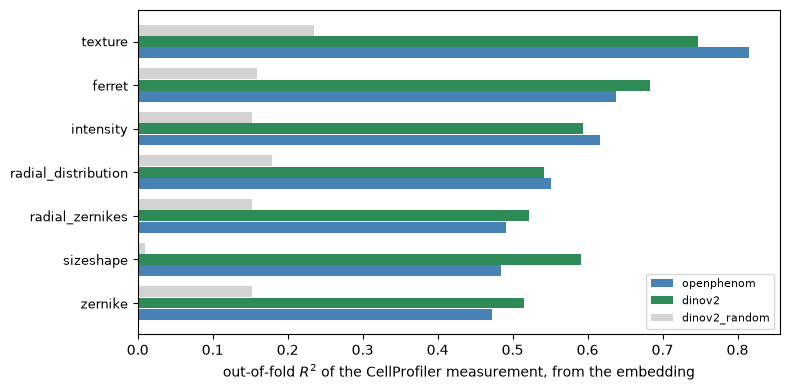

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))
panel = by_group.sort_values("openphenom")
positions = np.arange(len(panel))
for offset, name, colour in (
    (-0.26, "openphenom", "steelblue"),
    (0.0, "dinov2", "seagreen"),
    (0.26, "dinov2_random", "lightgrey"),
):
    ax.barh(positions + offset, panel[name], 0.25, label=name, color=colour)
ax.set_yticks(positions, panel.index, fontsize=9)
ax.set_xlabel("out-of-fold $R^2$ of the CellProfiler measurement, from the embedding")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

That is a vocabulary for the embedding, and it is specific enough to act on. Both trained models reconstruct
the *texture* measurements best, and the untrained model reconstructs little of anything — the gap between the
grey bars and the coloured ones is what training bought, measured in units a CellProfiler user already
understands.

Read that as a hint about which biology an embedding is built to see. Texture is the part of the named
profile both trained models carry best, so a phenotype that shows up mainly as a change of staining texture
is the kind most likely to survive swapping in an embedding. Which phenotypes that covers in a given assay is
a question for the assay, not for this table.

The two models agree on more than texture: both carry the Feret diameters second-best. They part most on the
size-and-shape measurements, which DINOv2 carries noticeably better than OpenPhenom does. So "an embedding"
is not one thing, and swapping one for another changes which phenotypes you can see; check your phenotype's
family against the model you plan to use. Only these two trained models were regressed here, so this says
nothing yet about SubCell or MorphEm.

The floor is not zero, either. A random projection of an image still carries some of a named measurement,
which is why the untrained control belongs in this plot as much as in the benchmark tables.

The same trick names the leading components, as far as it goes.

In [22]:
components = np.asarray(embedding.obsm["X_pca"])[:, :5]
values = np.asarray(aligned.X, dtype=float)
usable = np.isfinite(values).all(0) & (values.std(0) > 0)

# standard() is the one defined above, so the two tables are scaled the same way.
correlation = standard(components).T @ standard(values[:, usable]) / len(components)
names = aligned.var_names[usable]

rows = []
for index in range(components.shape[1]):
    best = np.argmax(np.abs(correlation[index]))
    rows.append(
        {
            "component": f"PC{index + 1}",
            "variance": round(float(embedding.uns["pca"]["variance_ratio"][index]), 3),
            "r with cell count": round(
                float(np.corrcoef(components[:, index], embedding.obs["Metadata_CellCount"])[0, 1]), 2
            ),
            "best named match": names[best],
            "r": round(float(correlation[index, best]), 2),
        }
    )
pd.DataFrame(rows).set_index("component")

,variance,r with cell count,best named match,r
component,,,,
PC1,0.635,-0.70,nuclei_3/max/radial_zernikesRadialDistribution...,0.76
PC2,0.166,-0.26,cell_4/max/radial_distributionRadialDistributi...,-0.82
PC3,0.059,-0.05,nuclei_1/max/intensityIntensity_MADIntensity,0.59
PC4,0.030,-0.10,nuclei_0/max/zernikeZernike_6_0,-0.55
PC5,0.020,-0.07,cell_3/max/intensityIntensity_StdIntensity,-0.35


The first two components have a named measurement that tracks them closely; by the fifth the best match
explains little. So the names are worth having for the leading components and not beyond. The same idea
applied to the embedding's own dimensions, rather than to its components, would give `pl.effect_sizes` and
`tl.feature_sets` something to key on again — borrowed rather than parsed, and honest as long as you say so.

## What the leading components actually are

The table above already hints at it. Measure it directly with `pc_regression`, per component.

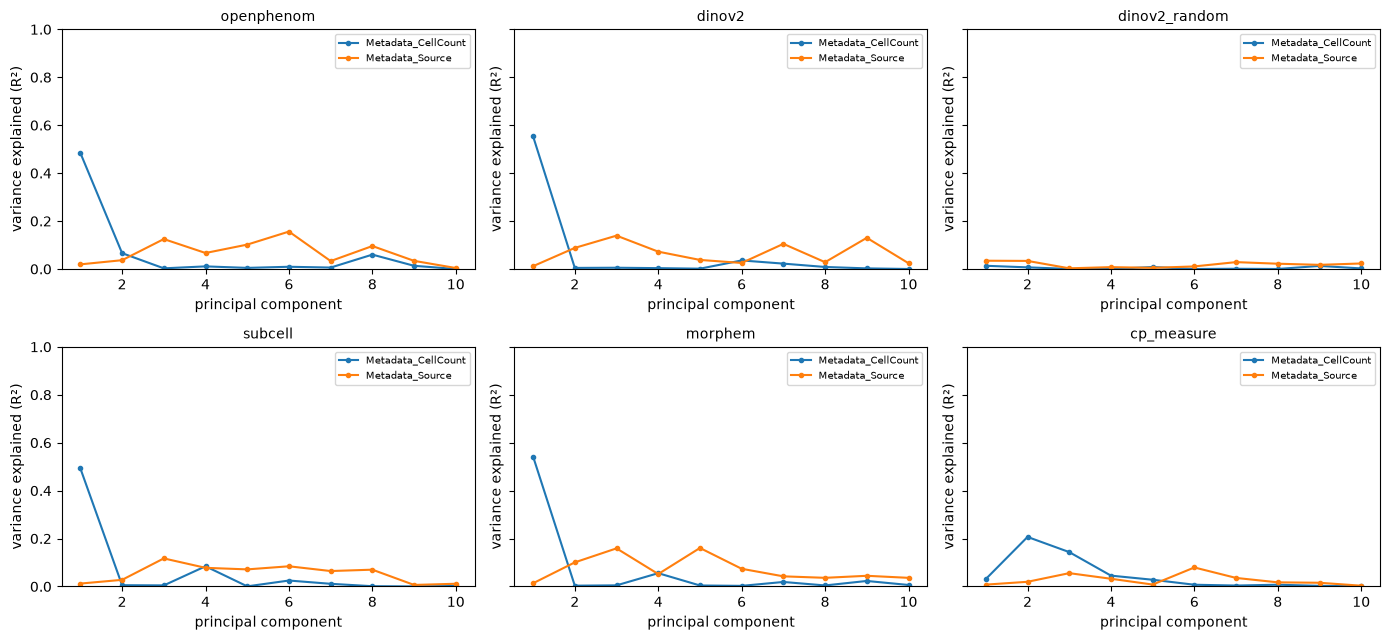

key,cell count,source,"first component, r with count"
openphenom,0.323,0.035,-0.696
dinov2,0.376,0.030,0.744
dinov2_random,0.015,0.019,-0.116
subcell,0.216,0.034,0.702
morphem,0.301,0.044,0.736
cp_measure,0.060,0.021,-0.176


In [23]:
fig, axes = plt.subplots(2, 3, figsize=(14, 6.5), sharey=True)
for ax, (model, wells) in zip(axes.ravel(), blocks.items(), strict=True):
    mt.pl.batch_variance(wells, keys=["Metadata_CellCount", "Metadata_Source"], use_rep="X_pca", n_comps=10, ax=ax)
    ax.set_title(model, fontsize=10)
fig.tight_layout()
plt.show()

variance = pd.concat(
    {
        model: mt.metrics.batch_variance_explained(
            wells, keys=["Metadata_CellCount", "Metadata_Source"], use_rep="X_pca"
        ).set_index("key")["value"]
        for model, wells in blocks.items()
    },
    axis=1,
).T.rename(columns={"Metadata_CellCount": "cell count", "Metadata_Source": "source"})
variance["first component, r with count"] = {
    model: float(np.corrcoef(wells.obsm["X_pca"][:, 0], wells.obs["Metadata_CellCount"])[0, 1])
    for model, wells in blocks.items()
}
variance.round(3)

On every trained embedding the first component correlates with the cell count at about 0.70 to 0.74 in
magnitude, against 0.18 for `cp_measure` and 0.12 for the untrained model. Read the first two columns against each
other: on the trained embeddings, over the fifty components, the count accounts for between six and twelve and a half
times as much of the variance as the laboratory does, on a
dataset whose whole design is four laboratories. The largest axis of these models tracks how full the well
is — which, as the next section shows, is itself partly a compound effect.

Two controls in that table say what the axis is:

- **`dinov2_random`, untrained, does not do it.** So it is not an artefact of the pipeline or of the images —
  the trained models *learned* to encode how full the well is.
- **`cp_measure` does it far less.** A CellProfiler-style feature is a per-cell measurement summarised over
  the well, which plausibly removes much of the dependence on how many cells there were. This page does not
  test that mechanism; it shows only that the count accounts for a small share of this block's variance.

Worth holding next to the table at the top of the page, where the untreated control wells already differed
1.7-fold in cell count between sites. If a good part of what separates the laboratories is how dense their
wells are, then a representation whose largest axis tracks density is one that entangles the batch with the
biology on that axis, which would be a reason embeddings need the correction more than `cp_measure` does. This
page does not test that. An endpoint count cannot tell seeding from growth, and it would take a density series
at one site to separate density from everything else a laboratory does differently.

For a page about swapping the feature block, that is the difference that matters most. The next section
asks the separate question of whether it changes which compounds look like hits.

## Is the hit a hit, or did the cells die?

This is the question a screener asks first, and on an embedding it is sharper than usual. Call hits, then ask
`tl.cytotoxicity` whether the compounds furthest from the controls are the ones that lost cells.

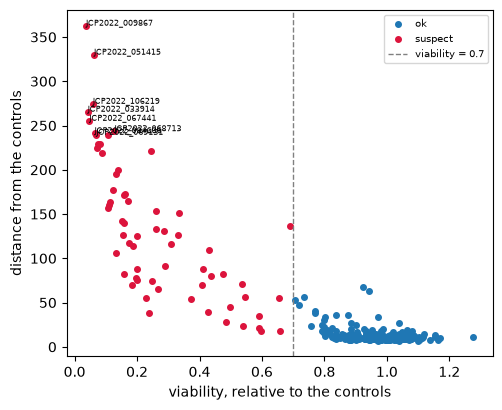

,"rho(distance, viability)",suspect,groups
model,,,
openphenom,-0.661,64,302
dinov2,-0.705,64,302
dinov2_random,-0.538,64,302
subcell,-0.736,64,302
morphem,-0.698,64,302
cp_measure,-0.700,64,302


In [24]:
toxicity = []
for model, wells in blocks.items():
    scratch = wells.copy()
    mt.tl.hit_calling(scratch, use_rep="X_pca", n_permutations=200, seed=0)
    mt.tl.cytotoxicity(scratch, site_key=None)  # one field per well, so there is no field count to divide by
    table = scratch.uns["mantispy"]["cytotoxicity"]
    toxicity.append(
        {
            "model": model,
            "rho(distance, viability)": float(table[["distance", "viability"]].corr(method="spearman").iloc[0, 1]),
            "suspect": int(table["suspect"].sum()),
            "groups": len(table),
        }
    )
    if model == "openphenom":
        mt.pl.cytotoxicity(scratch)
        plt.show()
pd.DataFrame(toxicity).set_index("model").round(3)

The `suspect` count is identical on every block, the untrained one included, which suggests that here it
follows viability alone: a compound is suspect when it has both lost cells and moved away from the controls,
and the ones below the viability cutoff appear to have moved on every block. The rank correlation is the part that varies. It is negative on **every** block, the
CellProfiler one included, between −0.54 for the
untrained model and −0.74 for SubCell. That is worth stating plainly, because it is easy to assume the embedding's
density axis makes it the more confounded representation: `cp_measure` is at −0.70, inside the range the trained embeddings span. Cell loss moves a profile away from the controls whichever way you measure it,
because a compound that kills cells has genuinely changed the well. The top of this screen's hit list is
partly a cytotoxicity ranking no matter which feature block you use.

What differs is where the count lands geometrically. On `cp_measure` it accounts for a small share of the
variance; on every trained embedding it tracks the largest component. That is a statement about the shape of
the representation, and this correlation, which asks only whether distance and cell loss rank together, is
not the measurement that would show it.

### So should the thin wells go?

The reflex is a floor under the cell count. Before reaching for it, look at which wells it removes.

In [25]:
# Normalizing and selecting never touched obs, so these are the counts as they were loaded.
well_table = embedding.obs
cell_counts = well_table["Metadata_CellCount"].to_numpy(dtype=float)
thin = cell_counts < 50

# Distinct laboratories, not thin wells: nineteen compounds sit in two wells of the same plate, so counting
# wells would call a compound reproducible on the strength of one laboratory twice.
laboratories = well_table[thin].groupby("Metadata_Perturbation", observed=True)["Metadata_Source"].nunique()
{
    "wells under 50 cells": int(thin.sum()),
    "of which controls": int(well_table["Metadata_Control"].to_numpy()[thin].sum()),
    "compounds thin at 2+ of the 4 laboratories": int((laboratories >= 2).sum()),
    "share of thin wells belonging to those": (
        f"{well_table['Metadata_Perturbation'][thin].map(laboratories).ge(2).mean():.0%}"
    ),
}

{'wells under 50 cells': 139,
 'of which controls': 2,
 'compounds thin at 2+ of the 4 laboratories': 33,
 'share of thin wells belonging to those': '83%'}

Almost none are control wells, and most belong to compounds that come out thin at more than one laboratory.
That points to the compound rather than a failed plate: it either killed the cells or stopped them dividing,
which an endpoint count cannot tell apart. One caveat is built into the design. All four laboratories ran the
same plate map, so a compound sits in the same well everywhere, and "thin at two laboratories" is also "the
same well thin at two laboratories". The edge is ruled out above; the rest of the plate is not. A cell-count
floor would strip replicates from exactly those compounds.

It is also not *only* that — the plate maps at the top of the page showed one laboratory running consistently
sparser than the others, so some of these wells are the plate and some are the compound. Both are true.

And it does not follow that the thin wells carry usable signal. Compare, within each stratum, how much more
alike two wells of the *same* compound are than two wells of different ones.

In [26]:
mt.tl.similarity(embedding, metric="cosine", use_rep="X_pca")
matrix = np.asarray(embedding.obsp["similarity"], dtype=float)
np.fill_diagonal(matrix, np.nan)

compound = embedding.obs["Metadata_Perturbation"].astype(str).to_numpy()
well_counts = embedding.obs["Metadata_CellCount"].to_numpy(dtype=float)
treated = ~embedding.obs["Metadata_Control"].to_numpy()

gaps = []
for label, keep in (
    ("thin (<50 cells)", treated & (well_counts < 50)),
    ("normal (50+)", treated & (well_counts >= 50)),
):
    rows = np.flatnonzero(keep)
    block = matrix[np.ix_(rows, rows)]
    same = compound[rows][:, None] == compound[rows][None, :]
    gaps.append(
        {
            "wells": label,
            "n": rows.size,
            "same compound": np.nanmedian(block[same]),
            "different": np.nanmedian(block[~same]),
        }
    )
gaps = pd.DataFrame(gaps).set_index("wells")
gaps["gap"] = gaps["same compound"] - gaps["different"]
gaps.round(3)

,n,same compound,different,gap
wells,,,,
thin (<50 cells),137,0.712,0.651,0.062
normal (50+),1143,0.751,0.519,0.232


Among the thin wells that gap shrinks to about a quarter of what it is in normal wells: two thin wells of
*different* compounds look almost as alike as two wells of the same one. Part of that is emptiness. Part of
it is probably the laboratory: these are unaligned components, and 44% of the thin wells come from
`source_4` against a quarter of all wells, so two different thin compounds are likely more often from the same
site than two replicates are. This table cannot separate the two.

So both readings were half right. The thin wells are largely an effect of the compound or of its well, which
this design cannot separate, and their profiles are nonetheless weak. Measure the two obvious remedies rather than choosing one on principle.

In [27]:
def remedy(treatment):
    """The recipe `prepared` ran, with a cell-count floor or with the count regressed out."""
    if treatment == "none":
        return blocks["openphenom"]  # already built above; rebuilding it is how the two quietly diverge
    wells = mt.ds.jump_lite("openphenom")
    if treatment == "floor":
        wells = wells[wells.obs["Metadata_CellCount"].to_numpy(dtype=float) >= 50].copy()
    mt.pp.normalize(wells, method="mad_robustize", by="Metadata_Plate", reference="negcon")
    # The same step `prepared` runs. It drops nothing from this embedding, and leaving it out is how the
    # floor and regress arms would end up compared against a "none" arm built a different way.
    mt.pp.feature_select(wells, operations=("drop_degenerate", "drop_na_columns"), na_cutoff=0.0)
    wells = mt.pp.subset_features(wells)
    if treatment == "regress":
        mt.pp.regress_out(wells, keys=("Metadata_CellCount",), by="Metadata_Plate")
    return align(wells)


remedies = []
for treatment in ("none", "floor", "regress"):
    trial = remedy(treatment)
    left = float(mt.metrics.pc_regression(trial, key="Metadata_CellCount", use_rep="X_pca")["value"].iloc[0])
    for rep in ("X_pca", "X_tvn", "X_harmony"):
        result = scored(treatment, trial, rep)
        remedies.append(
            {
                "treatment": treatment,
                "alignment": rep,
                "wells": trial.n_obs,
                "cell count variance": left,
                "mAP": result["mAP"],
                "significant": result["significant"],
                "target recall": result["target recall"],
                "recall null": result["recall null"],
                "recall p": result["recall p"],
            }
        )
pd.DataFrame(remedies).set_index(["treatment", "alignment"]).round(3)

wells  cell count variance    mAP  significant  \
treatment alignment                                                   
none      X_pca       1536                0.323  0.016            0   
          X_tvn       1536                0.323  0.018            3   
          X_harmony   1536                0.323  0.037            4   
floor     X_pca       1397                0.250  0.016            0   
          X_tvn       1397                0.250  0.020            3   
          X_harmony   1397                0.250  0.034           16   
regress   X_pca       1536                0.064  0.010            1   
          X_tvn       1536                0.064  0.018            3   
          X_harmony   1536                0.064  0.022            0   

                     target recall  recall null  recall p  
treatment alignment                                        
none      X_pca              0.057        0.066     0.851  
          X_tvn              0.127        0.091     0.010  
          X_harmony          0.067        0.081     0.970  
floor     X_pca              0.048        0.073     1.000  
          X_tvn              0.152        0.111     0.010  
          X_harmony          0.051        0.061     0.921  
regress   X_pca              0.127        0.093     0.010  
          X_tvn              0.161        0.114     0.010  
          X_harmony          0.109        0.086     0.010

Regressing the count out does what it says: it takes the density axis down, and target recall clears its own
null under all three alignments, where without it OpenPhenom cleared it only under TVN. What it costs shows up
in retrieval: the mAP falls on the unaligned components and under Harmony, and under Harmony the compounds
called drop from four to none.

The floor goes the other way, and it adds calls only under Harmony. There it lowers the mean mAP a little and raises the
compounds called from four to sixteen, the most cross-laboratory calls OpenPhenom makes on this page, while recall
stays below its null, as it was without the floor. On the unaligned components it changes
neither the calls nor the mAP.

Under TVN neither remedy costs anything this table scores: both match or beat keeping every well on mAP,
calls and recall, though the floor still discards 139 wells to do it. The trade is sharpest under Harmony,
where regressing buys annotation recall at the cost of retrieval and the floor buys calls at a small cost
in mAP. On the unaligned components only regressing buys anything. Each remedy buys something the other does
not, and that is the reason to stop rather than to pick a winner. For a **compound** screen the
cell count is partly a *treatment effect* — the compound reduced it — so regressing it out removes part of
the phenotype, not just a nuisance. The JUMP recipe regresses the cell count out of the ORF and CRISPR arms and
does not do it for compounds {cite:p}`Chandrasekaran_2023`, which is consistent with that reading.

This page keeps every well and does not regress, which is now a decision rather than an omission. Under
Harmony it has a price on both sides — the dozen or so compounds the floor would have added, and the annotation
recall regressing would have bought. On the unaligned components the price is mostly the recall, and under TVN
keeping every well is never the better choice on anything scored here. What to
do instead is ask the question directly, which is what `tl.cytotoxicity` above is for: report the cell count
beside the readouts, and know that on an embedding it is the first thing the model sees.

Two things that do not transfer:

- **`pp.well_qc` is for single-cell objects.** It counts the rows of each well, so on profiles that are
  already one row per well every well has one row, fails `min_cells`, and the whole plate is flagged. At well
  resolution the equivalent is a threshold on `obs["Metadata_CellCount"]` — the `floor` branch above.
- **scanpy's `sc.pp.filter_cells` and `sc.pp.filter_genes` threshold on counts**, and a morphological profile
  has no counts. The scanpy that does apply is `sc.pp.pca`, used above, and `sc.pp.neighbors` and
  `sc.tl.umap`, used in the next cell, which work because the object is an ordinary `AnnData`.

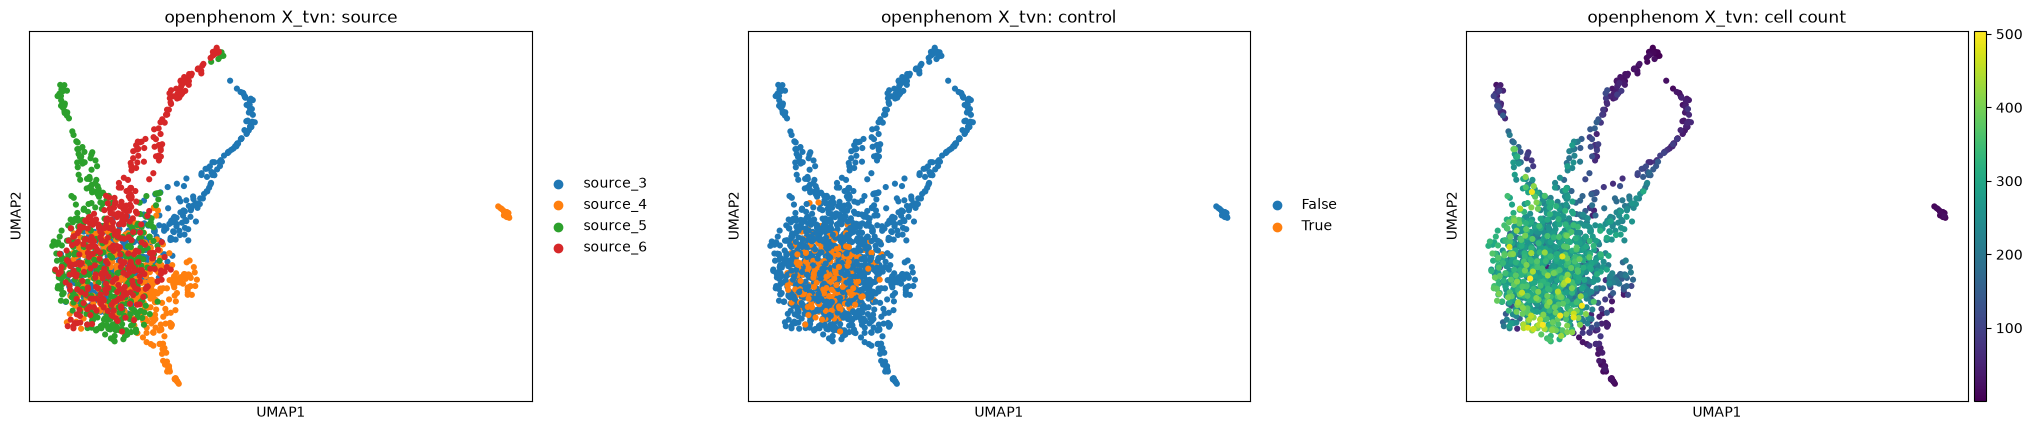

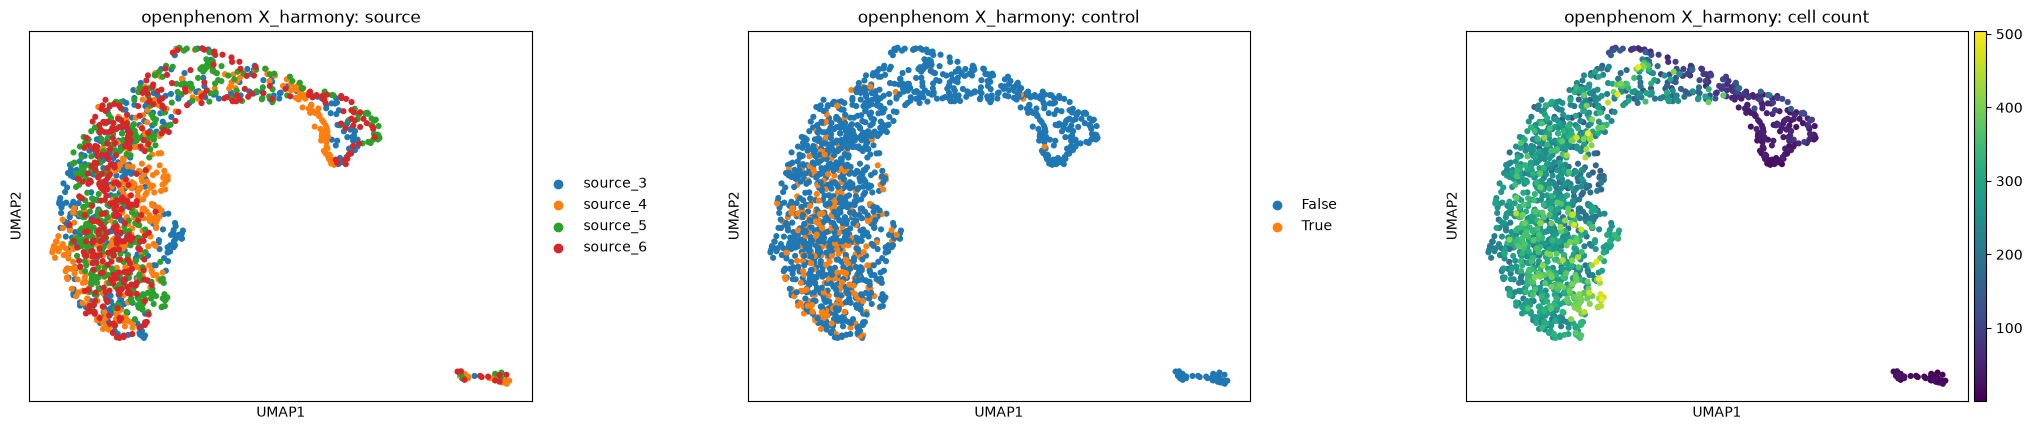

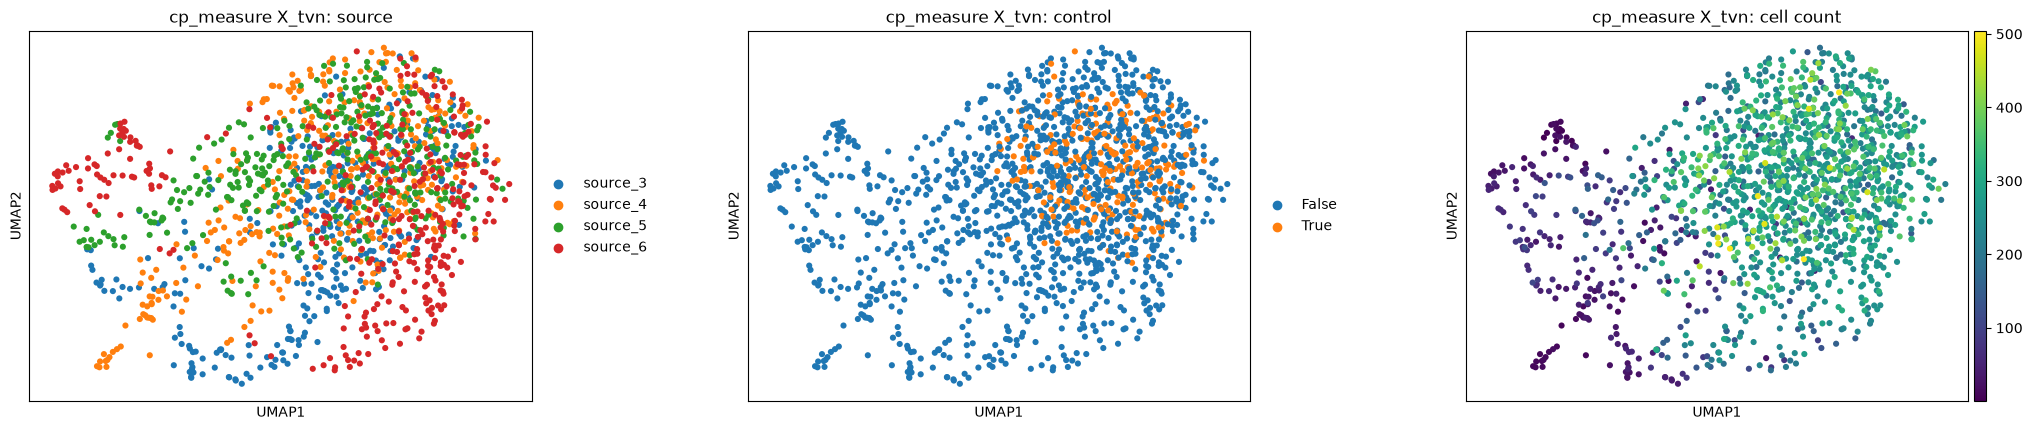

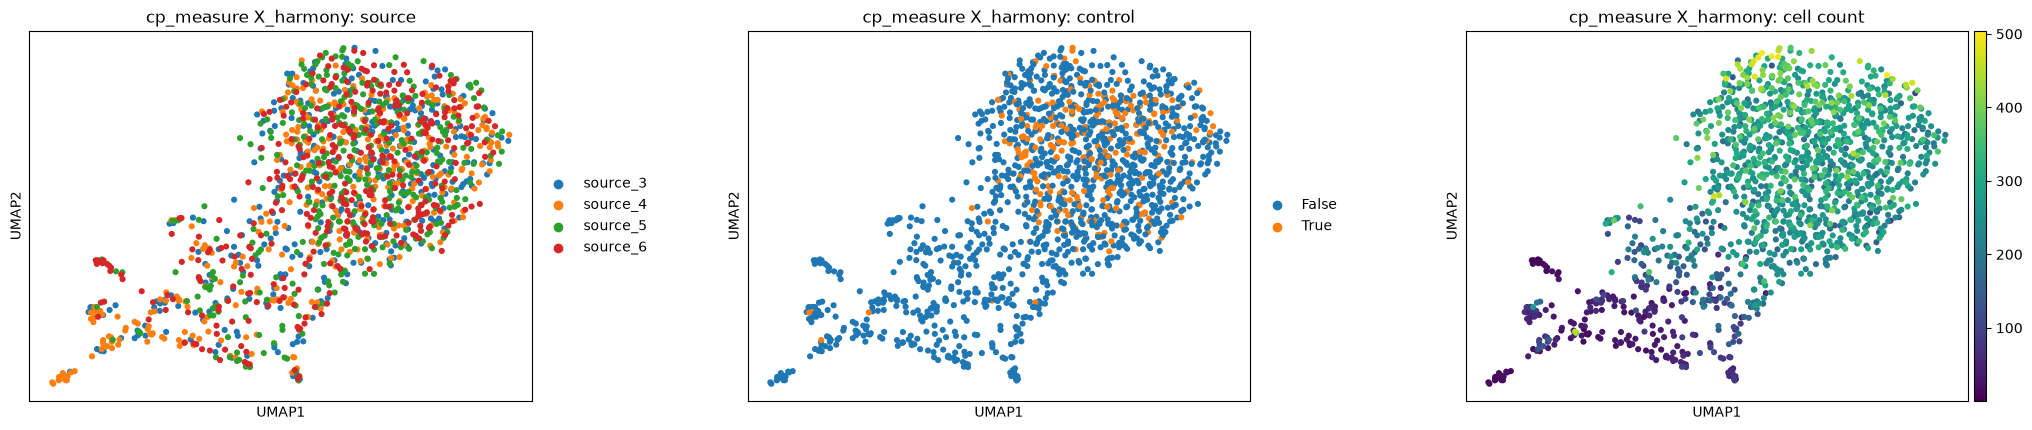

In [28]:
for model in ("openphenom", "cp_measure"):
    wells = blocks[model]
    for rep in ("X_tvn", "X_harmony"):
        sc.pp.neighbors(wells, use_rep=rep)
        sc.tl.umap(wells)
        sc.pl.umap(
            wells,
            color=["Metadata_Source", "Metadata_Control", "Metadata_CellCount"],
            wspace=0.3,
            title=[f"{model} {rep}: source", f"{model} {rep}: control", f"{model} {rep}: cell count"],
        )

Under TVN each source still throws off its own arm; under Harmony they interleave, which is what the
source-variance table already said. The difference between the two feature blocks is visible in the same
panels, and so is the cell-count gradient the previous section measured.

The detached island in the openphenom TVN panel is worth chasing rather than explaining away, and the third
panel already says what it is.

In [29]:
wells = blocks["openphenom"]
sc.pp.neighbors(wells, use_rep="X_tvn")
sc.tl.leiden(wells, key_added="tvn_cluster", flavor="igraph", n_iterations=2, directed=False)

medians = wells.obs.groupby("tvn_cluster", observed=True)["Metadata_CellCount"].median()
island = wells.obs[wells.obs["tvn_cluster"] == medians.idxmin()]
{
    "wells in the emptiest cluster": len(island),
    "sources": island["Metadata_Source"].value_counts()[lambda counts: counts > 0].to_dict(),
    "controls among them": int(island["Metadata_Control"].sum()),
    "median cell count": float(island["Metadata_CellCount"].median()),
    "median elsewhere": float(wells.obs["Metadata_CellCount"].drop(island.index).median()),
}

{'wells in the emptiest cluster': 14,
 'sources': {'source_4': 14},
 'controls among them': 0,
 'median cell count': 11.5,
 'median elsewhere': 252.0}

Clustering the same graph and taking the cluster with the lowest median cell count gives 14 wells, all from `source_4`,
none of them controls, with a median of 11.5 cells against 252 everywhere else — the same end of the scale the
cell-count panel puts the island at. All fourteen are from one laboratory, under an alignment that leaves the
laboratory in place, so this cannot separate emptiness from the site. An
embedding of a field holding a dozen cells is mostly background, and no correction can put back what the
image does not contain. The tables above told you that thin wells exist and that their profiles are weak;
only the embedding shows the emptiest of them pulling away into a group of their own. That is the argument for looking at
the embedding as well as the summary.

## Summary

What this screen said, on the same 1,536 wells measured six ways:

- **On telling a compound from DMSO, the blocks were close.** On phenotypic activity, one of the metrics the
  JUMP-Lite benchmark reports, the trained embeddings stayed close to `cp_measure`: MorphEm traded the lead
  with it, under TVN every trained embedding called more compounds active than it did, and OpenPhenom had the
  lowest mean mAP of the five real blocks under every alignment.
- **On telling compounds apart across laboratories without a correction, they were not.** Uncorrected,
  `cp_measure` called 32 of 301 compounds across the four sites and the learned embeddings none to five. Harmony
  narrowed that: MorphEm, SubCell and DINOv2 then reached a cross-laboratory mAP of 0.068 to 0.087 against
  `cp_measure`'s 0.074 and called 73 to 93 compounds against its 106, which fits embeddings that carry more of the laboratory. OpenPhenom called four
  even corrected.
- **The trained embeddings' largest axis tracks confluence.** Their first component correlates with the cell
  count at 0.70 to 0.74 in magnitude, against 0.18 for `cp_measure` and 0.12 for the untrained model, and over fifty
  components the count accounts for six to twelve and a half times as much of their variance as the laboratory does.
- **OpenPhenom and DINOv2 carry texture best.** Of the named measurement families, both reconstruct texture
  most faithfully and the Feret diameters next. They part on size and shape, so what else survives the swap
  depends on the model.
- **The classical block held up on annotation too.** In the main comparison `cp_measure` was the only block to
  recover annotated gene targets above its own null without TVN.
- **All of it is for off-the-shelf embeddings on lossy JUMP images, and one CellProfiler recipe.** Fine-tuning,
  other image preprocessing or the benchmark's rank transform could move any of these comparisons; the last of
  those halves `cp_measure`'s cross-laboratory calls under Harmony.
- **Distance from the controls tracks cell loss on every block**, the CellProfiler one included. Part of any
  hit list read off this screen reflects cell loss, whichever feature block it came from.

And how to work with one:

- An embedding is a feature matrix. Normalization, distances, hit calling, consensus and every metric work on
  it unchanged; `io.stamp` brings one you produced yourself onto the API surface. Cast it to float32 and join
  on the index, not on position.
- `var` carries no compartment or channel, so feature families, feature sets and the blocklist have nothing
  to key on. That is the embedding declining to answer, not missing data — and it is recoverable, because a
  block of named features on the same wells will name the embedding's first two or three components for you.
- Normalize per plate against the controls as usual. **Select features on a CellProfiler block and not on an
  embedding**, and say so. The pycytominer default is not enough on its own here: it leaves values of order
  1e5 in place, and it takes `drop_outliers` to bring them down to a few hundred.
- **Measure chance rather than assuming it**, with `known_relationships(n_permutations=...)`. When a few
  compounds carry most of the annotation, the shuffled-annotation level is a property of each representation,
  not a constant, and against a fixed 10% the untrained model would have looked like the best
  one without TVN. Keep an untrained model in the comparison: it is the cheapest check that a pipeline
  measures anything.
- **Use a large enough permutation null.** At 500 draws the p-value floor hid all 32 of `cp_measure`'s
  uncorrected calls. Use the default of 10,000.
- The three alignments disagree, and none dominates. Harmony is what lets the embeddings' compounds reproduce
  across sites; TVN is what lets their annotation recall clear its null. Decide which the screen needs, measure them all, and
  look at the embedding as well as the table.

Next: back to [8. Trustworthy features and experimental design](08_trustworthy_features_and_design.ipynb) for
the rest of the benchmarking vocabulary, or [4. Correcting and evaluating](04_correcting_and_evaluating.ipynb)
for the batch-correction methods this page compared TVN against.